# 05 - N: Interpretasi & Kesimpulan
**Kelompok 12 - Pariwisata Daerah Jawa Barat**

Tahap akhir OSEMN: menginterpretasikan hasil model, menarik insight, dan menyusun rekomendasi berdasarkan temuan dari tahap Explore dan Model.

---
## Dataset yang Digunakan

**1. Hasil Model 1** *(K-Means Clustering)* — `outputs/model_results/wisata_alam_clustered.csv`
Hasil segmentasi 71 kawasan wisata alam ke dalam 4 cluster

**2. Hasil Model 2** *(Regresi Linear)* — `outputs/model_results/hotel_tpk_predicted.csv`
Perbandingan TPK aktual vs prediksi model regresi (2019–2025)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
BG_COLOR      = '#0d1117'
PRIMARY_COLOR = '#00B4D8'
ACCENT_COLOR  = '#FF6B35'
GREEN_COLOR   = '#2ECC71'
PURPLE_COLOR  = '#9B59B6'
DPI           = 150
OUTPUT_DIR    = '../outputs/figures/'

CLUSTER_COLORS = ['#00B4D8', '#FF6B35', '#2ECC71', '#9B59B6']
CLUSTER_LABELS = {
    0: 'Perlu Evaluasi',
    1: 'Unggulan Terkelola',
    2: 'Andalan Lokal',
    3: 'Potensi Tersembunyi'
}

cluster_df = pd.read_csv('../outputs/model_results/wisata_alam_clustered.csv')
hotel_df   = pd.read_csv('../outputs/model_results/hotel_tpk_predicted.csv')

cluster_df['cluster_label'] = cluster_df['cluster'].map(CLUSTER_LABELS)

print(f'Clustering : {cluster_df.shape[0]} kawasan')
print(f'Hotel pred : {hotel_df.shape[0]} baris ({hotel_df["tahun"].min()}–{hotel_df["tahun"].max()})')

Clustering : 71 kawasan
Hotel pred : 84 baris (2019–2025)


---
## 1. Interpretasi Model 1: Segmentasi Kawasan Wisata Alam

In [2]:
# Ringkasan profil tiap cluster
profile = cluster_df.groupby(['cluster', 'cluster_label']).agg(
    n_kawasan       = ('pengelola_kawasan', 'count'),
    avg_pengunjung  = ('avg_pengunjung', 'mean'),
    years_active    = ('years_active', 'mean'),
    pct_wisman      = ('rasio_wisman', lambda x: round(x.mean() * 100, 2)),
    tipe_dominan    = ('tipe_pengelola', lambda x: x.mode()[0])
).reset_index().sort_values('cluster')

print('=== Profil Cluster Kawasan Wisata Alam ===')
for _, row in profile.iterrows():
    c = int(row['cluster'])
    print(f'\nCluster {c} — {row["cluster_label"]} (n={int(row["n_kawasan"])})')
    print(f'  Rata-rata pengunjung/tahun : {row["avg_pengunjung"]:,.0f}')
    print(f'  Rata-rata tahun aktif      : {row["years_active"]:.1f} / 5')
    print(f'  Proporsi wisman            : {row["pct_wisman"]:.2f}%')
    print(f'  Tipe pengelola dominan     : {row["tipe_dominan"]}')
    top3 = cluster_df[cluster_df['cluster'] == c].nlargest(3, 'avg_pengunjung')['pengelola_kawasan'].tolist()
    print(f'  Top 3 kawasan              : {", ".join(top3)}')

=== Profil Cluster Kawasan Wisata Alam ===

Cluster 0 — Perlu Evaluasi (n=45)
  Rata-rata pengunjung/tahun : 3,822
  Rata-rata tahun aktif      : 1.1 / 5
  Proporsi wisman            : 0.06%
  Tipe pengelola dominan     : LAINNYA
  Top 3 kawasan              : CURUG CISUREN, WH CURUG CILEMBER, CURUG CIGENTIS

Cluster 1 — Unggulan Terkelola (n=13)
  Rata-rata pengunjung/tahun : 50,768
  Rata-rata tahun aktif      : 3.7 / 5
  Proporsi wisman            : 1.27%
  Tipe pengelola dominan     : TWA
  Top 3 kawasan              : TWA TANGKUBANPARAHU, TAHURA IR. H. DJUANDA, BALAI TN. GN. CIREMAI

Cluster 2 — Andalan Lokal (n=5)
  Rata-rata pengunjung/tahun : 3,108
  Rata-rata tahun aktif      : 3.4 / 5
  Proporsi wisman            : 0.40%
  Tipe pengelola dominan     : LAINNYA
  Top 3 kawasan              : CURUG CIMAHI, CITUMANG, TB MASIGIT KAREUMBI

Cluster 3 — Potensi Tersembunyi (n=8)
  Rata-rata pengunjung/tahun : 9,168
  Rata-rata tahun aktif      : 1.2 / 5
  Proporsi wisman            :

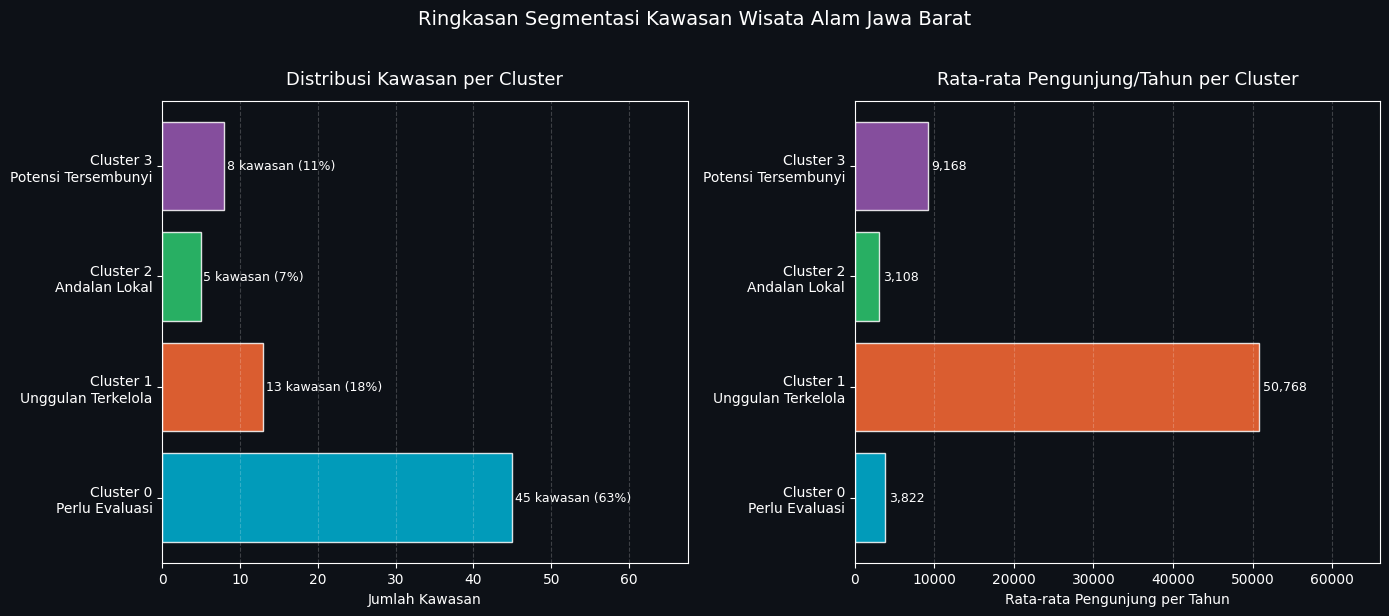

Saved: interpret_cluster_ringkasan.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
for ax in axes:
    ax.set_facecolor(BG_COLOR)

# Kiri: jumlah kawasan per cluster
labels = [f'Cluster {c}\n{CLUSTER_LABELS[c]}' for c in profile['cluster']]
counts = profile['n_kawasan'].tolist()
colors = [CLUSTER_COLORS[c] for c in profile['cluster']]

bars = axes[0].barh(labels, counts, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{int(val)} kawasan ({int(val)/len(cluster_df)*100:.0f}%)',
                 va='center', fontsize=9, color='white')
axes[0].set_title('Distribusi Kawasan per Cluster', fontsize=13, pad=12)
axes[0].set_xlabel('Jumlah Kawasan')
axes[0].set_xlim(0, max(counts) * 1.5)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.2)

# Kanan: rata-rata pengunjung per cluster
avg_vals = profile['avg_pengunjung'].tolist()
bars2 = axes[1].barh(labels, avg_vals, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars2, avg_vals):
    axes[1].text(bar.get_width() + 500, bar.get_y() + bar.get_height() / 2,
                 f'{val:,.0f}',
                 va='center', fontsize=9, color='white')
axes[1].set_title('Rata-rata Pengunjung/Tahun per Cluster', fontsize=13, pad=12)
axes[1].set_xlabel('Rata-rata Pengunjung per Tahun')
axes[1].set_xlim(0, max(avg_vals) * 1.3)
axes[1].grid(True, axis='x', linestyle='--', alpha=0.2)

plt.suptitle('Ringkasan Segmentasi Kawasan Wisata Alam Jawa Barat', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}interpret_cluster_ringkasan.png', dpi=DPI, facecolor=BG_COLOR, bbox_inches='tight')
plt.show()
print('Saved: interpret_cluster_ringkasan.png')

**Insight Model 1 — Segmentasi Kawasan Wisata Alam:**

**Cluster 0 — Perlu Evaluasi (63% kawasan):**
Mayoritas kawasan masuk kelompok ini. Hampir seluruhnya hanya melapor 1 tahun dari 5 tahun normal, dengan kunjungan sangat rendah. Ini mengindikasikan masalah sistemik pelaporan data, bukan semata-mata sepi pengunjung.

**Cluster 1 — Unggulan Terkelola (18% kawasan):**
Kawasan dengan pengelolaan formal (TN/TWA/TAHURA), konsisten melapor 3–4 tahun, dan mendominasi total kunjungan. TWA Tangkubanparahu (337K/tahun) dan TAHURA Djuanda (114K/tahun) adalah kontributor utama.

**Cluster 2 — Andalan Lokal (7% kawasan):**
Kawasan non-formal (LAINNYA) yang konsisten melapor 3–4 tahun. Volume kecil tapi reliable. Contoh: Curug Cimahi, Citumang — objek wisata lokal yang stabil.

**Cluster 3 — Potensi Tersembunyi (11% kawasan):**
Kawasan dengan status pengelolaan formal (TN/TWA) tetapi hanya melapor 1–2 tahun. Ini adalah anomali: ada potensi tapi tidak termonitor. Contoh: TN Gede Pangrango, TN Halimun-Salak.

---
## 2. Interpretasi Model 2: Regresi Linear TPK Hotel

In [4]:
train_df = hotel_df[hotel_df['split'] == 'train']
test_df  = hotel_df[hotel_df['split'] == 'test']

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2_train  = r2_score(train_df['tpk_aktual'], train_df['tpk_prediksi'])
r2_test   = r2_score(test_df['tpk_aktual'],  test_df['tpk_prediksi'])
rmse_test = np.sqrt(mean_squared_error(test_df['tpk_aktual'], test_df['tpk_prediksi']))
mae_test  = mean_absolute_error(test_df['tpk_aktual'],  test_df['tpk_prediksi'])

# Koefisien dari model (disimpan hardcoded dari hasil run 04_model.ipynb)
coef_data = {
    'Fitur'      : ['tahun_norm', 'sin_bulan', 'cos_bulan', 'is_covid_int'],
    'Koefisien'  : [-1.6288, -1.1783, 4.3560, -12.5259],
    'Interpretasi': [
        'TPK turun ~1.6 ppt per tahun (belum pulih ke 2019)',
        'Bulan Mar–Jun sedikit lebih rendah (low season)',
        'Bulan Des–Jan lebih tinggi (peak season)',
        'COVID turunkan TPK rata-rata 12.5 ppt/bulan'
    ]
}
coef_df = pd.DataFrame(coef_data)

print('=== Metrik Model 2 ===')
print(f'R² (train 2019–2024) : {r2_train:.4f}')
print(f'R² (test 2025)       : {r2_test:.4f}')
print(f'RMSE (test)          : {rmse_test:.4f}')
print(f'MAE  (test)          : {mae_test:.4f}')
print(f'\n=== Koefisien Regresi ===')
print(coef_df.to_string(index=False))

=== Metrik Model 2 ===
R² (train 2019–2024) : 0.5133
R² (test 2025)       : 0.1066
RMSE (test)          : 4.4965
MAE  (test)          : 3.3049

=== Koefisien Regresi ===
       Fitur  Koefisien                                       Interpretasi
  tahun_norm    -1.6288 TPK turun ~1.6 ppt per tahun (belum pulih ke 2019)
   sin_bulan    -1.1783    Bulan Mar–Jun sedikit lebih rendah (low season)
   cos_bulan     4.3560           Bulan Des–Jan lebih tinggi (peak season)
is_covid_int   -12.5259        COVID turunkan TPK rata-rata 12.5 ppt/bulan


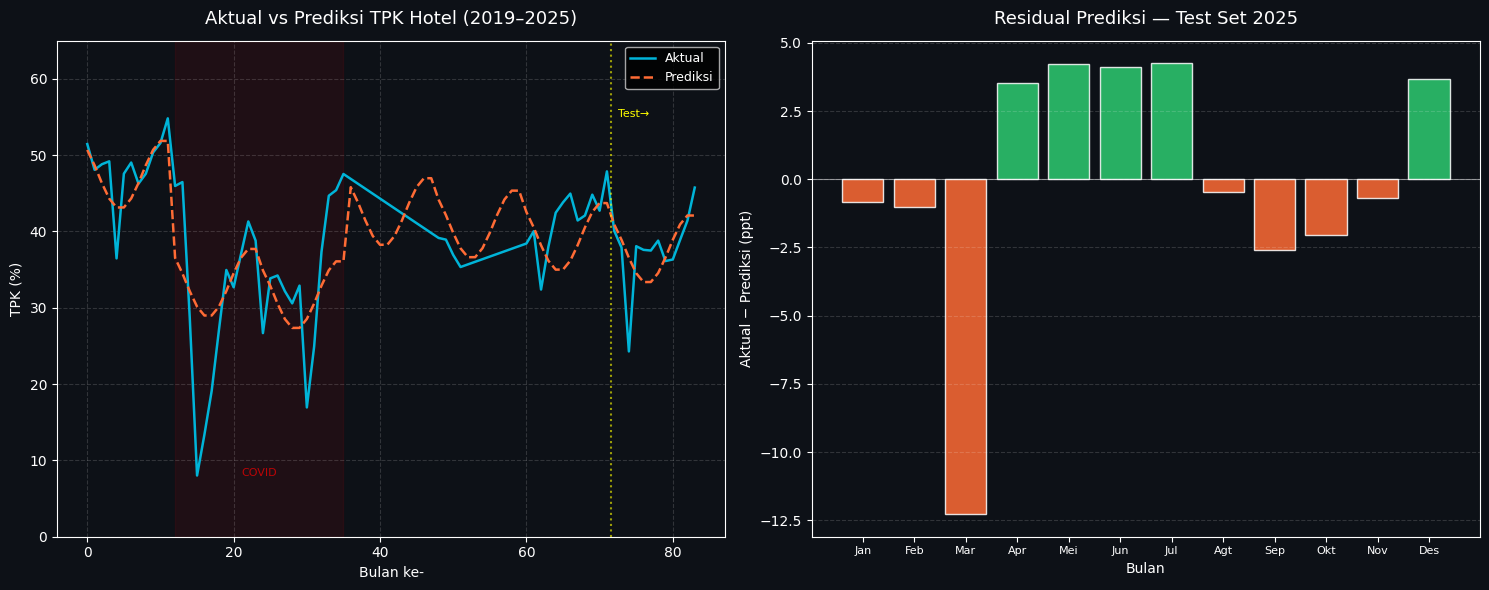

Saved: interpret_regresi_ringkasan.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor(BG_COLOR)
for ax in axes:
    ax.set_facecolor(BG_COLOR)

# Kiri: aktual vs prediksi seluruh periode
idx_all = list(range(len(hotel_df)))
axes[0].plot(idx_all, hotel_df['tpk_aktual'],   color=PRIMARY_COLOR, linewidth=1.8, label='Aktual')
axes[0].plot(idx_all, hotel_df['tpk_prediksi'], color=ACCENT_COLOR,  linewidth=1.8, linestyle='--', label='Prediksi')

n_train = len(train_df)
axes[0].axvline(n_train - 0.5, color='yellow', linestyle=':', alpha=0.6, linewidth=1.5)
axes[0].text(n_train - 0.5, 55, '  Test→', color='yellow', fontsize=8)

# Shading COVID (index 12–35 = tahun 2020-2021)
covid_mask = hotel_df.index[(hotel_df['tahun'].isin([2020, 2021]))]
if len(covid_mask) > 0:
    axes[0].axvspan(covid_mask[0], covid_mask[-1], alpha=0.08, color='red')
    axes[0].text((covid_mask[0] + covid_mask[-1]) / 2, 8, 'COVID', color='red', ha='center', fontsize=8, alpha=0.7)

axes[0].set_title('Aktual vs Prediksi TPK Hotel (2019–2025)', fontsize=13, pad=12)
axes[0].set_xlabel('Bulan ke-')
axes[0].set_ylabel('TPK (%)')
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.15)
axes[0].set_ylim(0, 65)

# Kanan: residual (error) per bulan pada test set
test_idx = list(range(len(test_df)))
residuals = test_df['tpk_aktual'].values - test_df['tpk_prediksi'].values
bar_colors = [GREEN_COLOR if r >= 0 else ACCENT_COLOR for r in residuals]
axes[1].bar(test_df['bulan_num'].values, residuals, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='white', linewidth=0.8, alpha=0.5)
axes[1].set_title('Residual Prediksi — Test Set 2025', fontsize=13, pad=12)
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Aktual − Prediksi (ppt)')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agt','Sep','Okt','Nov','Des'], fontsize=8)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.15)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}interpret_regresi_ringkasan.png', dpi=DPI, facecolor=BG_COLOR)
plt.show()
print('Saved: interpret_regresi_ringkasan.png')

**Insight Model 2 — Regresi Linear TPK Hotel:**

**Faktor paling dominan — Dampak COVID (`is_covid_int = −12.5`):**
COVID adalah variabel dengan pengaruh terbesar. Periode 2020–2021 merenggut rata-rata 12.5 poin persentase TPK per bulan dibanding kondisi normal.

**Tren waktu negatif (`tahun_norm = −1.6`):**
TPK mengalami penurunan sekitar 1.6 ppt per tahun bahkan setelah memperhitungkan COVID. Ini menunjukkan pemulihan pasca-pandemi berjalan lambat — TPK 2024 (rata-rata ~41%) masih di bawah level 2019 (48.4%).

**Pola musiman (`cos_bulan = +4.4`, `sin_bulan = −1.2`):**
Desember–Januari secara konsisten menjadi peak season, sedangkan Maret–Juni menjadi low season. Efek ini terukur dan reproducible.

**Performa model (R² test = 0.107):**
R² rendah pada test set 2025 terutama disebabkan anomali Maret 2025 (aktual 24.3% vs prediksi 36.6%). Model ini lebih tepat digunakan sebagai alat **eksplanatif** — untuk memahami faktor-faktor yang mempengaruhi TPK — daripada sebagai alat prediksi jangka panjang.

---
## 3. Rekomendasi

**Wisata Alam — dari Model 1**

**1. Prioritaskan pengembangan Cluster 1 (Unggulan Terkelola)**
13 kawasan TN/TWA/TAHURA sudah terbukti mampu menarik pengunjung. Fokus investasi infrastruktur dan promosi di kelompok ini untuk memaksimalkan dampak pariwisata.

**2. Investigasi Cluster 3 (Potensi Tersembunyi)**
8 kawasan formal (TN/TWA) yang jarang melapor — ini anomali. Perlu audit: apakah kawasan tidak aktif, ataukah ada masalah sistem pelaporan di unit-unit ini?

**3. Tinjau ulang sistem pelaporan Cluster 0 (Perlu Evaluasi)**
45 kawasan (63%) hanya melapor 1 tahun dari 5 tahun normal. Rekomendasi: standardisasi kewajiban pelaporan tahunan untuk semua kawasan yang masih aktif beroperasi.

---

**Hotel TPK — dari Model 2**

**4. Strategi promosi di low season (Maret–Juni)**
Model mengonfirmasi pola musiman: bulan Maret–Juni secara konsisten memiliki TPK lebih rendah. Paket wisata, diskon, atau event MICE di periode ini dapat meratakan okupansi sepanjang tahun.

**5. Monitor pemulihan pasca-COVID**
Tren `tahun_norm` negatif (−1.6 ppt/tahun) menunjukkan pemulihan belum kembali ke level 2019. TPK 2025 perlu dipantau ketat; anomali Maret 2025 (24.3%) perlu diselidiki penyebabnya.

---
## 4. Kesimpulan

Studi ini menganalisis dua aspek pariwisata Jawa Barat menggunakan kerangka OSEMN pada dua dataset utama.

**Model 1: Segmentasi Kawasan Wisata Alam**
Metode K-Means Clustering (k=4, Silhouette=0.669) menghasilkan 4 kelompok kawasan dengan karakteristik berbeda. 63% kawasan masuk "Perlu Evaluasi" — indikator masalah sistemik dalam pelaporan data wisata alam. Hanya 18% kawasan yang terklasifikasi "Unggulan Terkelola", namun kelompok ini mendominasi total kunjungan.

**Model 2: Faktor Penentu TPK Hotel**
Regresi Linear (R²_train=0.513, R²_test=0.107) menemukan bahwa COVID menurunkan TPK 12.5 ppt/bulan — faktor terbesar. Tren pemulihan berjalan negatif (−1.6 ppt/tahun), belum kembali ke level pra-pandemi. Pola musiman nyata: peak Desember, low Maret–Juni.

**Keterbatasan:**
- Data DISHUT hanya 5 tahun kualitas NORMAL (2016–2019, 2021)
- Regresi linear belum cukup untuk prediksi 2025 yang akurat
- Cross-dataset DISHUT × Hotel hanya 2 titik data bersih